# Lab 7  - Recap Exercises for Exam

# ❗❗❗ Very important administrative detail

The lab changes its content once every **TWO WEEKS**.

*   week 1 & week 2 - lab 1
*   week 3 & week 4 - lab 2
*   week 5 & week 6 - lab 3
*   week 7 & week 8 - lab 4
*   week 9 & week 10 - lab 5
*   week 11 & week 12 - lab 6
*   week 13 & week 14 - lab 7


In [1]:
import pymc as pm

# Exercise 1

The number of heads out of 100 coin tosses is 40 and we want to monitor the bias of the coin. Write a prior in PyMC that you would use in modeling given the likelihood:


```
heads = pm.Binomial('heads', n=100, p=theta, observed=40)
```



In [ ]:
with pm.Model() as model:
	theta = pm.Uniform('theta', lower=0, upper=1)	# sau Beta(1, 1)

# Exercise 2

Write the PyMC (complete) code to compute the bias of a 6-sided dice when you know that in 60 throws you get the following results:
   * no. of 1s: 11
   * no. of 2s: 12
   * no. of 3s: 10
   * no. of 4s: 6
   * no. of 5s: 9
   * no. of 6s: 12

In [7]:
with pm.Model() as model:
    p = pm.Dirichlet('p', a=[1, 1, 1, 1, 1, 1])
    obs = pm.Multinomial('obs', n=60, p=p, observed=[11, 12, 10, 6, 9, 12])
    step = pm.NUTS()
    trace = pm.sample(2000, step=step)

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 54 seconds.


       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
p[0]  0.182  0.048   0.094    0.269      0.001    0.001    8225.0    5784.0   
p[1]  0.198  0.050   0.111    0.294      0.001    0.001    8975.0    5263.0   
p[2]  0.166  0.047   0.079    0.251      0.000    0.001    9091.0    5567.0   
p[3]  0.105  0.038   0.041    0.180      0.000    0.000    7947.0    4574.0   
p[4]  0.151  0.044   0.075    0.233      0.000    0.001    8488.0    4945.0   
p[5]  0.197  0.050   0.106    0.288      0.001    0.001    8475.0    6663.0   

      r_hat  
p[0]    1.0  
p[1]    1.0  
p[2]    1.0  
p[3]    1.0  
p[4]    1.0  
p[5]    1.0  


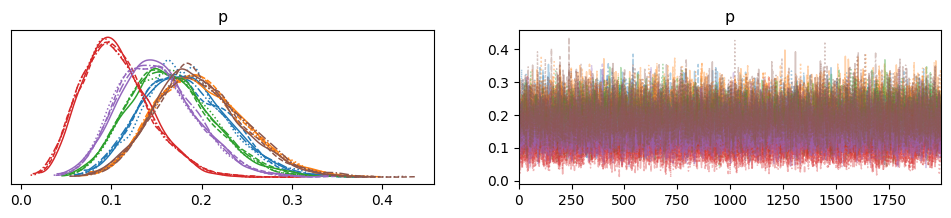

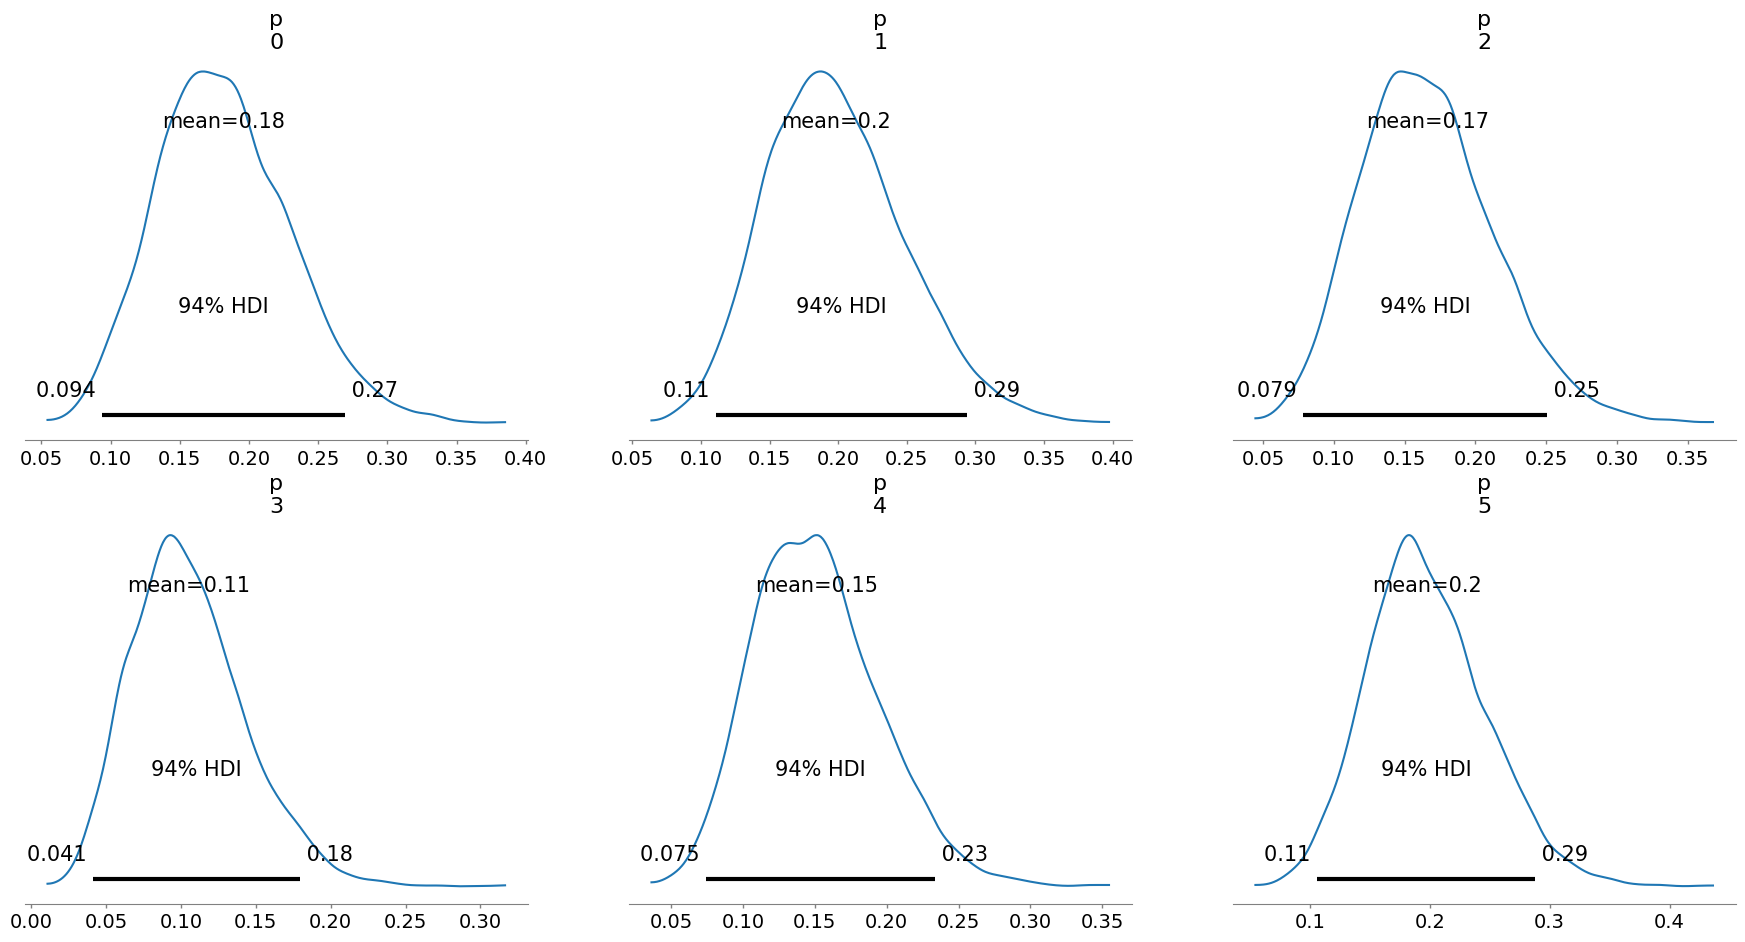

In [10]:
import arviz as az
az.plot_trace(trace)
az.plot_posterior(trace)
trace_summary = az.summary(trace)
print(trace_summary)

# Exercise 3

A fire prevention checklist contains $N$ boxes to check. $N$ changes depending on legislature and you are part of a team detecting a change point in the number of checkboxes during the years. Write the PyMC likelihood term that you should use knowing that the observed data is stored in array y_obs.


In [ ]:
# answer:
mu = 3.00
y_obs = []
with pm.Model() as model:
    N = pm.Poisson('N', mu=mu, obs=y_obs)

In [ ]:
# Expected number of checkboxes before and after the change
lambda_1 = pm.Exponential("lambda_1", 1.0)
lambda_2 = pm.Exponential("lambda_2", 1.0)

# Change point (year index)
tau = pm.DiscreteUniform("tau", lower=0, upper=len(y_obs) - 1)

# Piecewise mean
lambda_t = pm.math.switch(
    pm.math.arange(len(y_obs)) <= tau,
    lambda_1,
    lambda_2
)

# Likelihood
y = pm.Poisson("y", mu=lambda_t, observed=y_obs)

# Exercise 4

Model this Bayesian Network in PyMC that simulates two alarms in a modern steel foundry factory. The observed data is $C=1$. Compute the posteriors for M (Maufacturing Alarm) and S (Security Alarm).


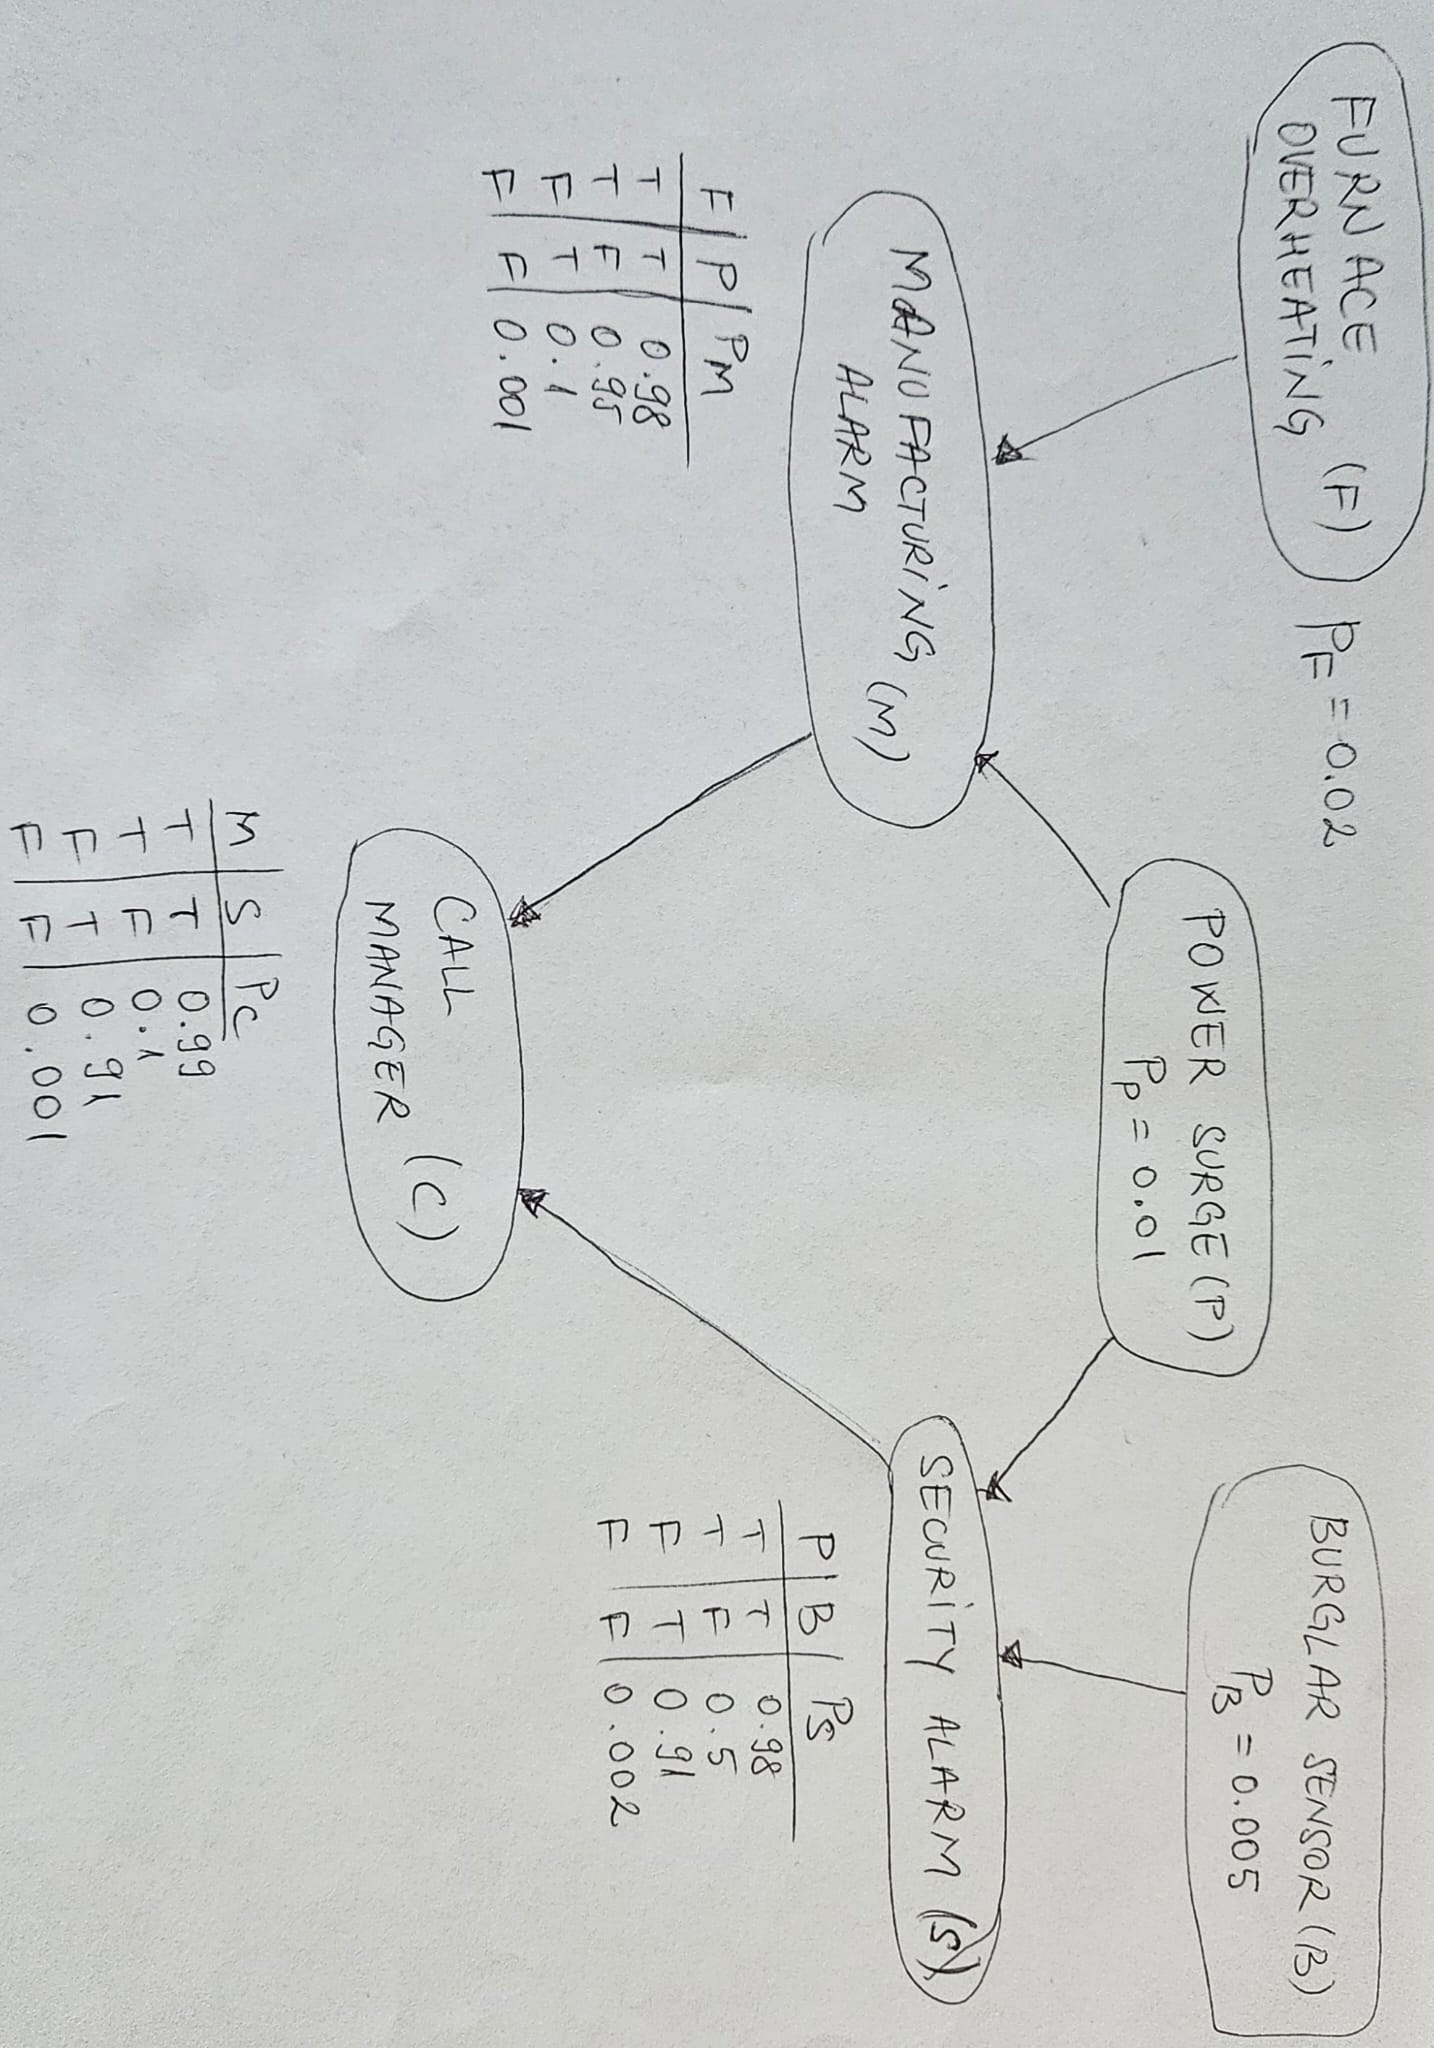

In [ ]:
from IPython.display import Image
Image('BN.jpeg')

In [3]:
with pm.Model() as model:
    F = pm.Bernoulli('F', p=0.02)
    B = pm.Bernoulli('B', p=0.005)
    P = pm.Bernoulli('P', p=0.01)
    p_M = pm.math.switch(F, pm.math.switch(P, 0.98, 0.95), pm.math.switch(P, 0.1, 0.001))
    M = pm.Bernoulli('M', p=p_M)
    p_S = pm.math.switch(P, pm.math.switch(B, 0.98, 0.5), pm.math.switch(B, 0.91, 0.002))
    S = pm.Bernoulli('S', p=p_S)
    p_C = pm.math.switch(M, pm.math.switch(S, 0.99, 0.1), pm.math.switch(S, 0.91, 0.001))
    C = pm.Bernoulli('C', p=p_C, observed=1)
    trace = pm.sample(2000)

Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [F, B, P, M, S]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 19 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'F'}>, <Axes: title={'center': 'B'}>,
        <Axes: title={'center': 'P'}>],
       [<Axes: title={'center': 'M'}>, <Axes: title={'center': 'S'}>,
        <Axes: >]], dtype=object)

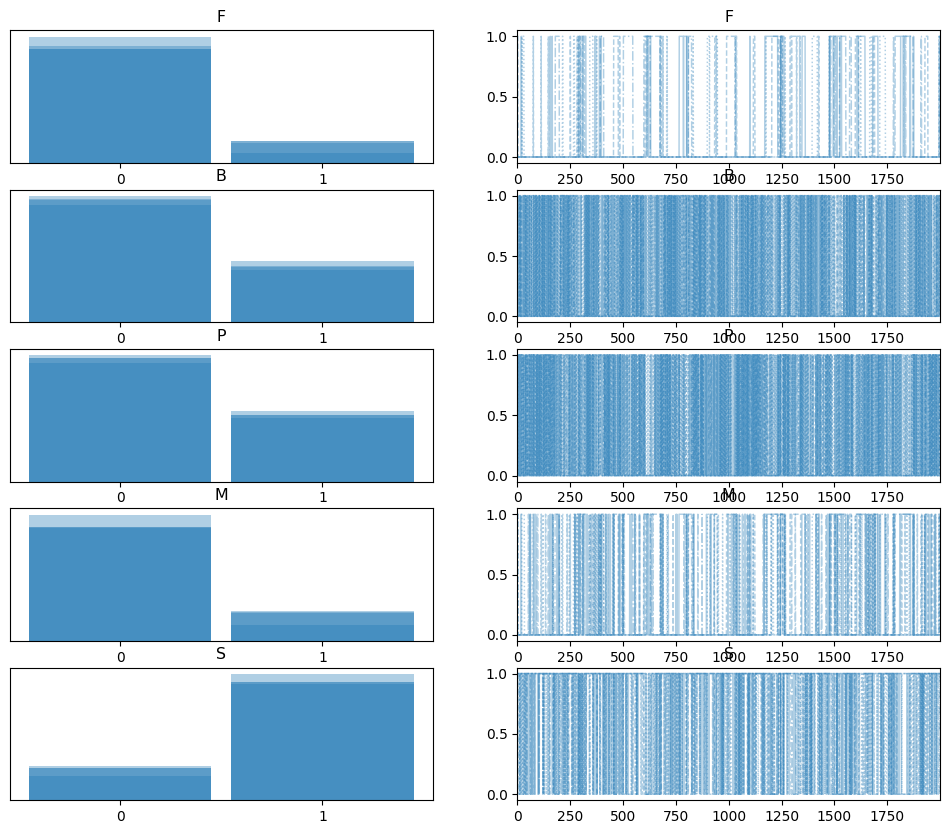

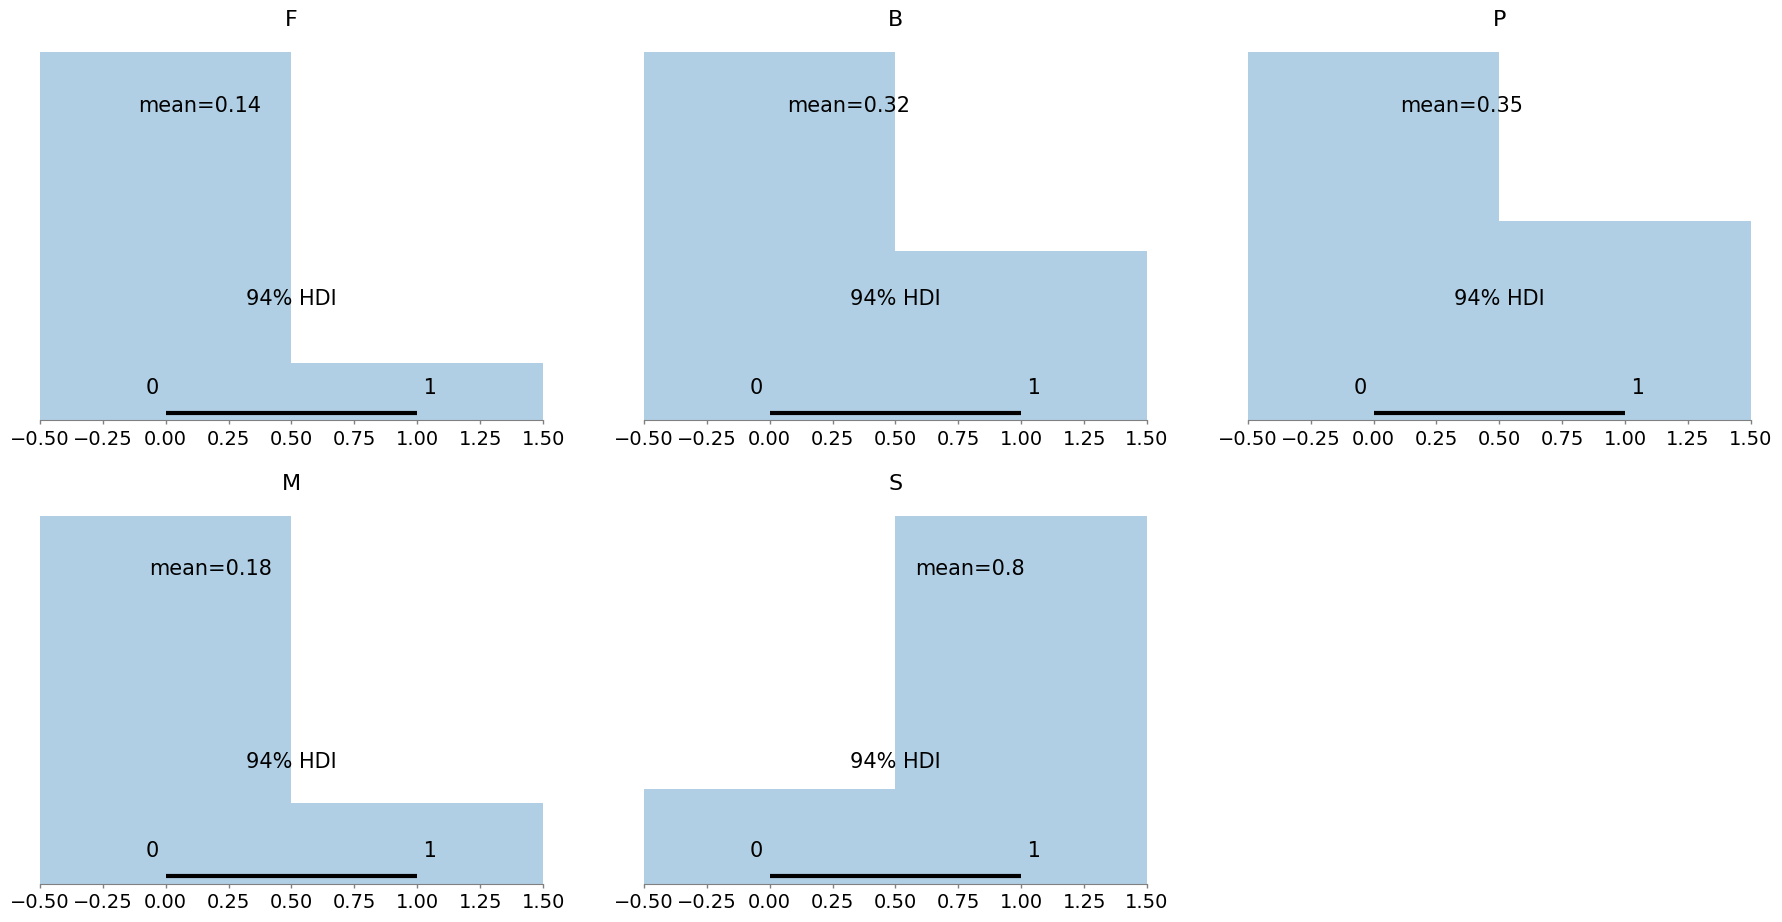

: 

In [ ]:
import arviz as az
az.plot_trace(trace)
az.plot_posterior(trace)

# Exercise 5

For an experiment, 20 basketball players from two teams (team A and team B) make 100 attempts to score 2-pointers. The number of achieved 2-pointer shots is recorded in a dataset for each player in the following csv:



```
player_id, team_name, 2p_achieved
John Doe, team A, 25
Alice, team B, 35
Frank, team A, 15
Bob, team B, 10
...
```
Marge wants to join one of the teams but is unsure which one is better. Help her decide using PyMC and bayesian inference.


In [ ]:
# answer:
import pymc as pm
import numpy as np

with pm.Model() as model:

    # Team-level shooting probabilities
    theta_team = pm.Beta("theta_team", alpha=1, beta=1, shape=2)
    # theta_team[0] = team A
    # theta_team[1] = team B

    # Player outcomes
    y = pm.Binomial(
        "y",
        n=100,
        p=theta_team[team_idx],
        observed=y_obs
    )

    trace = pm.sample(2000, target_accept=0.9)

In [ ]:
prob_B_better = (trace.posterior["theta_team"][:, :, 1] > trace.posterior["theta_team"][:, :, 0]).mean()